<a href="https://colab.research.google.com/github/Shandu16/capstone-predictive-engine/blob/main/Bank_marketing_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import zipfile
import urllib.request

# Downloading and extractiin of UCI Bank Marketing dataset
url = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"
urllib.request.urlretrieve(url, "bank.zip")

with zipfile.ZipFile("bank.zip", "r") as zip_ref:
    zip_ref.extractall("bank_extracted")
with zipfile.ZipFile("bank_extracted/bank-additional.zip", "r") as zip_ref:
    zip_ref.extractall("bank_data")

# Load the dataset
df = pd.read_csv("bank_data/bank-additional/bank-additional-full.csv", sep=";")
print(f"Dataset loaded! Shape: {df.shape}")

Dataset loaded! Shape: (41188, 21)


In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Target encoding: convert 'yes'/'no' to 1/0
df['target'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)
X = df.drop(columns=['y', 'target'])
y = df['target']

# 2. Drop 'duration' to prevent data leakage (as noted in UCI documentation)
X = X.drop(columns=['duration'])

# 3. Scale numerical features
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])
print("Preprocessing complete.")

Preprocessing complete.


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# 1. One-hot encode categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 2. Train-test split (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Apply SMOTE to fix class imbalance
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print("Feature Engineering & SMOTE complete.")

Feature Engineering & SMOTE complete.


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train_resampled, y_train_resampled)
y_pred_xgb = xgb_model.predict(X_test)

print("--- Model 1: XGBoost ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb))

--- Model 1: XGBoost ---
Accuracy: 0.8852
              precision    recall  f1-score   support

           0       0.94      0.93      0.94     10965
           1       0.49      0.51      0.50      1392

    accuracy                           0.89     12357
   macro avg       0.71      0.72      0.72     12357
weighted avg       0.89      0.89      0.89     12357



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)
y_pred_rf = rf_model.predict(X_test)

print("--- Model 2: Random Forest ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

--- Model 2: Random Forest ---
Accuracy: 0.8674
              precision    recall  f1-score   support

           0       0.95      0.90      0.92     10965
           1       0.44      0.62      0.51      1392

    accuracy                           0.87     12357
   macro avg       0.69      0.76      0.72     12357
weighted avg       0.89      0.87      0.88     12357



In [6]:
from sklearn.metrics import roc_auc_score, confusion_matrix

# Calculate advanced metrics for XGBoost
roc_auc_xgb = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1])
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)

print("--- Model 1 (XGBoost) Advanced Performance ---")
print(f"ROC-AUC Score: {roc_auc_xgb:.4f}")
print(f"Confusion Matrix:\n{conf_matrix_xgb}")

--- Model 1 (XGBoost) Advanced Performance ---
ROC-AUC Score: 0.7994
Confusion Matrix:
[[10231   734]
 [  685   707]]


In [7]:
# Calculate advanced metrics for Random Forest
roc_auc_rf = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

print("--- Model 2 (Random Forest) Advanced Performance ---")
print(f"ROC-AUC Score: {roc_auc_rf:.4f}")
print(f"Confusion Matrix:\n{conf_matrix_rf}")

--- Model 2 (Random Forest) Advanced Performance ---
ROC-AUC Score: 0.8077
Confusion Matrix:
[[9858 1107]
 [ 531  861]]


--- Statistical Comparison ---
XGBoost ROC-AUC:       0.7994
Random Forest ROC-AUC: 0.8077


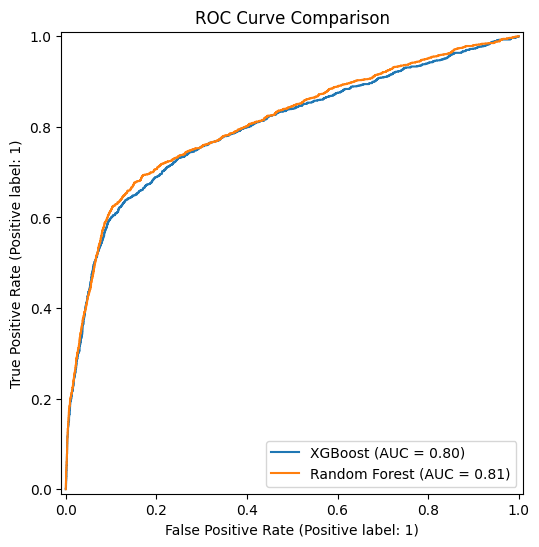

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

# Compare the statistical performance visually and numerically
print("--- Statistical Comparison ---")
print(f"XGBoost ROC-AUC:       {roc_auc_xgb:.4f}")
print(f"Random Forest ROC-AUC: {roc_auc_rf:.4f}")

# Plot ROC Curves for comparison
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(xgb_model, X_test, y_test, ax=ax, name="XGBoost")
RocCurveDisplay.from_estimator(rf_model, X_test, y_test, ax=ax, name="Random Forest")
plt.title("ROC Curve Comparison")
plt.show()